# Monthly standardized forecast errors: RMSE and MAE

Archive-backed companion to `6a_shock_ts.ipynb`.

**Configure → inventory/cache plan → reuse or prepare 6a monthly indices →
monthly standardized RMSE/MAE → first-member and ensemble-mean comparison →
seasonal lead-time detail.**

Model and reference anomalies use one observed calendar-month climatology over the
selected reference period. Errors are normalized by the corresponding observed
calendar-month variability. The individual anomalies remove the observed seasonal
cycle, while their difference retains systematic model error.


In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

repo_root = next((p for p in (Path.cwd(), Path.cwd().parent) if (p / 'esp_lab').is_dir()), None)
if repo_root is not None:
    sys.path.insert(0, str(repo_root))
    
from importlib import reload
from esp_lab.diagnostics import initial_shock_error as initial_shock_error_diagnostic
from esp_lab import env_paths

from workflows.diagnostics import initial_shock_error_archive as initial_shock_error_archive_workflow

from esp_lab.utils.dask_util import DaskConfig, get_cluster_client
from esp_lab.utils.resource_utils import ResourceTracker

initial_shock_error_diagnostic = reload(initial_shock_error_diagnostic)
plot_error_heatmap = initial_shock_error_diagnostic.plot_error_heatmap

initial_shock_error_archive_workflow = reload(initial_shock_error_archive_workflow)
plan_archive_run = initial_shock_error_archive_workflow.plan_archive_run
compute_archive_plan = initial_shock_error_archive_workflow.compute_archive_plan

## User setup and workflow configuration

The primary metric reduces the 24 paired monthly standardized errors within each
initialization. The seasonal supplement reduces the three constituent monthly errors
for each verification season and lead year. Raw-unit RMSE and MAE are retained in the
tables; normalized RMSE is the primary visual quantity.

`FORCE_COMPUTE=False` reuses every valid exact-period cache and prepares only missing
or stale products. Set it to `True` to rebuild the selected products at the same paths.


In [2]:
# mode for derivation of variables choices (archive-backed initial-shock caches):
# "auto": automatically determine whether to rebuild or use cached results
# "rebuild": force recomputation
# "require": require cached results and fail if not available
derivation_mode = "auto"

# True to force recomputation of block-index and RMSE/MAE caches, False (default) to use cached results if available
recompute_shock = False

field = 'TS' # Surface temperature
#field = 'TREFHT' # Surface air temperature
#field = 'PRECT' # Precipitation
#field = 'PSL' # Sea level pressure

VAR_CONFIG = {
    'TREFHT': dict(obs_product='ERA5', obs_variable='tas', units='degC',
                   model_scale=1., model_offset=-273.15, smyle_scale=1., smyle_offset=-273.15,
                   obs_scale=1., obs_offset=-273.15),
    'TS': dict(obs_product='ERA5', obs_variable='ts', units='degC',
               model_scale=1., model_offset=-273.15, smyle_scale=1., smyle_offset=-273.15,
               obs_scale=1., obs_offset=-273.15),
    'PRECT': dict(obs_product='GPCP_v2.3', obs_variable='PRECT', units='mm/day',
                  model_scale=86400000., model_offset=0., smyle_scale=86400000., smyle_offset=0.,
                  obs_scale=1., obs_offset=0.),
    'PSL': dict(obs_product='ERA5', obs_variable='psl', units='hPa',
                model_scale=.01, model_offset=0., smyle_scale=.01, smyle_offset=0.,
                obs_scale=.01, obs_offset=0.),
}
variable = dict(VAR_CONFIG[field], field=field, model_variable=field, smyle_variable=field)

FORCE_COMPUTE = recompute_shock

E3SM_CASES = {
    'E3SM-FOSIRL': dict(case_prefix='WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL', cache_tag='JRA55_FOSIRL'),
    'E3SM-Reanalysis': dict(case_prefix='WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce', cache_tag='Reanalysis'),
    'E3SM-4DEnVarOcn': dict(case_prefix='WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_4DEnVarOcn', cache_tag='4DEnVarOcn'),
}

YEAR_START = 1980
YEAR_END = 2011
CLIMATOLOGY_YEARS = (1981, 2010)
init_months = [5, 11]
nlead = 24

WORKFLOW_SETTINGS = {
    'paths': {
        's2d_diag_root': str(env_paths.s2d_diag_root()),
        'figure_outdir': str(env_paths.figure_root()),
        'table_outdir': str(env_paths.s2d_diag_root() / 'multimodel' / 'initial_shock' / 'tables'),
    },
    'run': {
        'years': [YEAR_START, YEAR_END], 'init_months': init_months,
        'nlead': nlead, 'smoke_mode': False,
    },
    'e3sm': {
        'data_dir': str(env_paths.raw_model_root()),
        'nens': 10, 'grid': '180x360_aave', 'ts_split': '2yr', 'engine': 'netcdf4',
        'chunks': {'Y': 3, 'L': 24, 'M': 2, 'lat': 90, 'lon': 180},
    },
    'smyle': {
        'include': True, 'nens': 20,
        'benchmark_dir': str(env_paths.s2d_diag_root() / 'CESM-SMYLE'),
        'chunks': {'Y': 3, 'L': 24, 'M': 2, 'lat': 96, 'lon': 144},
    },
    'obs': {
        'data_dir': str(env_paths.obs_root()),
        'chunks': {'time': 24, 'lat': 90, 'lon': 180},
    },
    'regrid': {
        'target_dlat': 5.0, 'target_dlon': 5.0,
        'method': 'conservative', 'periodic': True,
    },
    'metric': {
        'window_months': 24, 'block_months': 12, 'start_lead': 0,
        'min_samples': None, 'monthly_error_min_samples': None,
        'seasonal_error_min_samples': 3, 'min_area_fraction': .9,
        'climatology_years': list(CLIMATOLOGY_YEARS),
    },
    'cache': {'mode': derivation_mode, 'force_compute': FORCE_COMPUTE},
    'dask': {
        'enabled': True, 'cluster_type': 'local', 'workers': 4,
        'memory_limit': '4GB',
    },
}
if WORKFLOW_SETTINGS['run']['smoke_mode']:
    E3SM_CASES = {'E3SM-FOSIRL': E3SM_CASES['E3SM-FOSIRL']}
    WORKFLOW_SETTINGS['run'].update(years=[1980, 1981], init_months=[11])
    WORKFLOW_SETTINGS['dask']['workers'] = 2

print('Field:', field, '| Initialization years:', WORKFLOW_SETTINGS['run']['years'])
print('Observed climatology:', WORKFLOW_SETTINGS['metric']['climatology_years'])
print('Force compute:', WORKFLOW_SETTINGS['cache']['force_compute'])


Field: TS | Initialization years: [1980, 2011]
Observed climatology: [1981, 2010]
Force compute: False


## Inventory and cache plan

Inventory all requested initializations before expensive processing. The plan first
checks the shared 6a monthly-index caches and then the compact monthly-error caches.
Cache identities include the exact period, inputs, settings, and numerical algorithms.


In [3]:
archive_plan = plan_archive_run(WORKFLOW_SETTINGS, E3SM_CASES, variable)
plan_table = pd.DataFrame([
    {'case': t['case'], 'init_month': t['month'], 'initializations': len(t['years']),
     'source_files': len(t['inventory']),
     'block_indices': 'prepare' if t['rebuild'] else 'reuse',
     'rmse_mae': 'prepare' if t['error_rebuild'] else 'reuse',
     'cache': t['error_path']}
    for t in archive_plan
])
display(plan_table)


,case,init_month,initializations,source_files,block_indices,rmse_mae,cache
0,E3SM-FOSIRL,5,32,321,reuse,reuse,/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FO...
1,E3SM-Reanalysis,5,32,321,reuse,reuse,/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/Reanalys...
2,E3SM-4DEnVarOcn,5,32,321,reuse,reuse,/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/4DEnVarO...
3,CESM-SMYLE,5,32,2,reuse,reuse,/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMY...
4,E3SM-FOSIRL,11,32,321,reuse,reuse,/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FO...
5,E3SM-Reanalysis,11,32,321,reuse,reuse,/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/Reanalys...
6,E3SM-4DEnVarOcn,11,32,321,reuse,reuse,/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/4DEnVarO...
7,CESM-SMYLE,11,32,2,reuse,reuse,/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMY...


## Dask resources

Start after the inventory succeeds. A local cluster starts only when the plan contains
work to rebuild; rerunning this cell closes any previous cluster. The computation cell
always releases Dask resources, including when computation raises an exception.


In [4]:
from esp_lab.utils.notebook_resources import restart_notebook_cluster, close_notebook_resources

needs_distributed_compute = (
    WORKFLOW_SETTINGS['dask']['enabled']
    and any(task['rebuild'] or task['error_rebuild'] for task in archive_plan)
)
cluster, client, workflow_resources = restart_notebook_cluster(
    globals(),
    lambda: get_cluster_client(DaskConfig(
        cluster_type=WORKFLOW_SETTINGS['dask']['cluster_type'],
        workers=WORKFLOW_SETTINGS['dask']['workers'],
        memory_limit=WORKFLOW_SETTINGS['dask']['memory_limit'],
    )) if needs_distributed_compute else (None, None),
)
if client is not None:
    display(client)
elif WORKFLOW_SETTINGS['dask']['enabled']:
    print('All exact-period caches are valid; skipped distributed cluster startup.')


Dask scheduler: local threads
All exact-period caches are valid; skipped distributed cluster startup.


## Shared monthly indices and error metrics

The workflow reuses 6a's shared-reference monthly products whenever they are valid.
For each initialization, normalized RMSE and MAE use paired monthly errors

\[
e_t = \frac{m_t-o_t}{\sigma_{\mathrm{obs},\,month(t)}}.
\]

The same calculation is made for the first ensemble member and ensemble mean. Raw
RMSE/MAE remain available in physical units. Seasonal diagnostics retain lead year
and verification season and use their three monthly errors.


In [5]:
try:
    comparison_by_month = compute_archive_plan(archive_plan, WORKFLOW_SETTINGS, variable)
finally:
    close_notebook_resources(globals())
    print('Closed Dask resources after computation.')

for month, comparison in comparison_by_month.items():
    print(f'Initialization month {month:02d}')
    display(comparison[[
        'normalized_rmse', 'normalized_mae',
        'first_member_normalized_rmse', 'first_member_normalized_mae',
        'rmse', 'mae', 'paired_sample_count', 'valid_metric',
    ]])


Reusing E3SM-FOSIRL init 05: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FOSIRL/initial_shock/metrics/atm/TS/JRA55_FOSIRL_init05_1980_2011.nc
Reusing E3SM-Reanalysis init 05: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/Reanalysis/initial_shock/metrics/atm/TS/Reanalysis_init05_1980_2011.nc
Reusing E3SM-4DEnVarOcn init 05: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/4DEnVarOcn/initial_shock/metrics/atm/TS/4DEnVarOcn_init05_1980_2011.nc
Reusing CESM-SMYLE init 05: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/initial_shock/metrics/atm/TS/CESM-SMYLE_init05_1980_2011.nc
Reusing E3SM-FOSIRL init 11: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/JRA55_FOSIRL/initial_shock/metrics/atm/TS/JRA55_FOSIRL_init11_1980_2011.nc
Reusing E3SM-Reanalysis init 11: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/Reanalysis/initial_shock/metrics/atm/TS/Reanalysis_init11_1980_2011.nc
Reusing E3SM-4DEnVarOcn init 11: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/4DEnVarOcn/initial_shock/metrics/atm/TS/4DEnVarOcn_init11_1980_2011.nc
Reusing CES

<xarray.Dataset> Size: 8kB
Dimensions:                       (case: 4, Y: 32)
Coordinates:
  * case                          (case) object 32B 'E3SM-FOSIRL' ... 'CESM-S...
  * Y                             (Y) int64 256B 1980 1981 1982 ... 2010 2011
Data variables:
    normalized_rmse               (case, Y) float64 1kB 1.861 1.719 ... 3.587
    normalized_mae                (case, Y) float64 1kB 1.528 1.607 ... 3.469
    first_member_normalized_rmse  (case, Y) float64 1kB 1.967 1.698 ... 3.417
    first_member_normalized_mae   (case, Y) float64 1kB 1.536 1.536 ... 3.291
    rmse                          (case, Y) float64 1kB 0.3982 0.3631 ... 0.745
    mae                           (case, Y) float64 1kB 0.3194 0.3337 ... 0.716
    paired_sample_count           (case, Y) int64 1kB 24 24 24 24 ... 24 24 24
    valid_metric                  (case, Y) int8 128B 1 1 1 1 1 1 ... 1 1 1 1 1
Attributes:
    diagnostic_version:            initial_shock_rmse_mae_v3
    min_samples:                   24
    seasonal_min_samples:          3
    anomaly_baseline:              shared reference-observation calendar-mont...
    normalized_error_denominator:  observed calendar-month climatological sta...
    error_reduction:               paired standardized monthly errors within ...
    interpretation:                forecast error amplitude in observed month...
    field:                         TS
    init_month:                    5

Initialization month 11


<xarray.Dataset> Size: 8kB
Dimensions:                       (case: 4, Y: 32)
Coordinates:
  * case                          (case) object 32B 'E3SM-FOSIRL' ... 'CESM-S...
  * Y                             (Y) int64 256B 1980 1981 1982 ... 2010 2011
Data variables:
    normalized_rmse               (case, Y) float64 1kB 1.562 1.672 ... 4.131
    normalized_mae                (case, Y) float64 1kB 1.394 1.561 ... 4.038
    first_member_normalized_rmse  (case, Y) float64 1kB 1.737 1.695 ... 4.283
    first_member_normalized_mae   (case, Y) float64 1kB 1.622 1.532 ... 4.187
    rmse                          (case, Y) float64 1kB 0.3346 0.354 ... 0.8533
    mae                           (case, Y) float64 1kB 0.2917 0.3258 ... 0.8292
    paired_sample_count           (case, Y) int64 1kB 24 24 24 24 ... 24 24 24
    valid_metric                  (case, Y) int8 128B 1 1 1 1 1 1 ... 1 1 1 1 1
Attributes:
    diagnostic_version:            initial_shock_rmse_mae_v3
    min_samples:                   24
    seasonal_min_samples:          3
    anomaly_baseline:              shared reference-observation calendar-mont...
    normalized_error_denominator:  observed calendar-month climatological sta...
    error_reduction:               paired standardized monthly errors within ...
    interpretation:                forecast error amplitude in observed month...
    field:                         TS
    init_month:                    11

## Primary comparison: first member and ensemble mean

Rows are initialization months and columns compare the first ensemble member with the
ensemble mean. Each cell summarizes all paired monthly errors in the 24-month window.
Lower normalized RMSE indicates closer agreement with the reference observation.


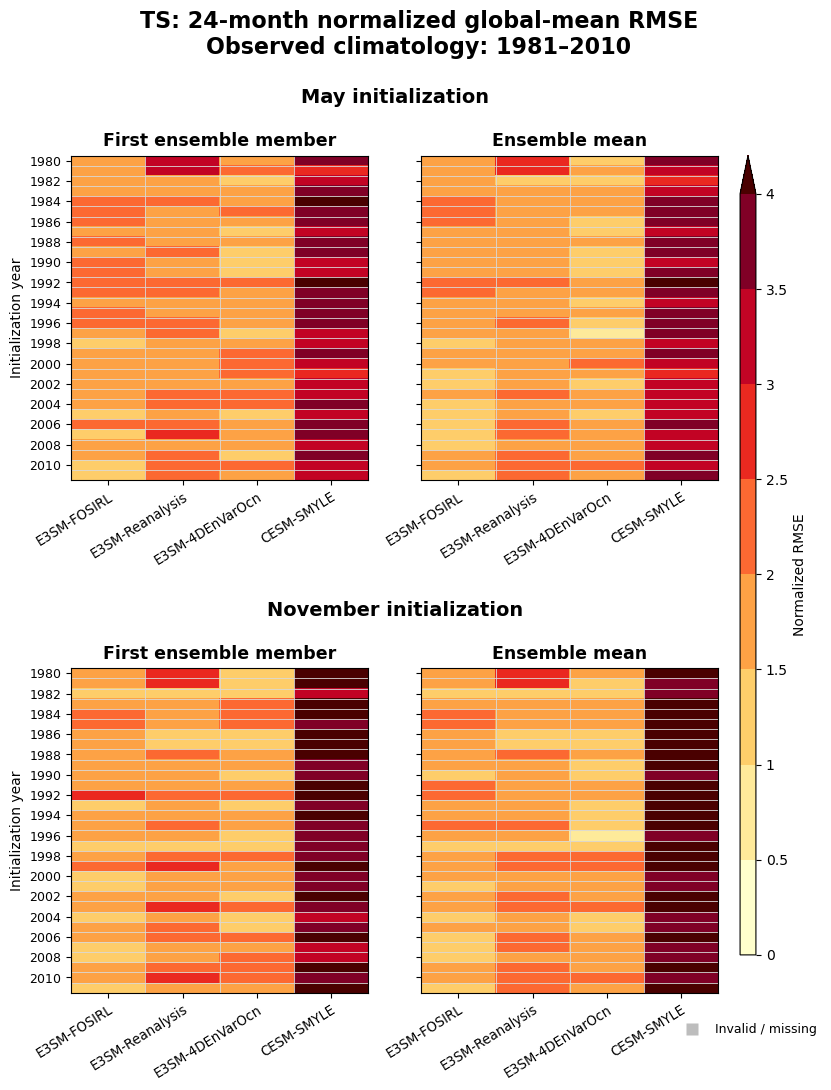

Saved primary monthly-error comparison: /global/cfs/cdirs/e3sm/www/zhan391/e3sm-s2d_diag/fig_shock_error_ts_init1980-2011_clim1981-2010_monthly_normalized_rmse.png


In [6]:
# ===================================================================
# SETUP & PLOT CONTROLS
# Shared helpers read these controls when called by this plotting cell.
# ===================================================================
fontz = 16
TITLE_FONTSIZE = fontz * 1.0
ROW_TITLE_FONTSIZE = fontz * 0.875
PANEL_FONTSIZE = fontz * 0.78125
LABEL_FONTSIZE = fontz * 0.625
X_TICK_FONTSIZE = fontz * 0.59375
Y_TICK_FONTSIZE = fontz * 0.5625
COLORBAR_TICK_FONTSIZE = fontz * 0.625
LEGEND_FONTSIZE = fontz * 0.5625

FIGSIZE = (8.8, 10.8)
SUBPLOTS_ADJUST = dict(left=.105, right=.84, bottom=.065, top=.84,
                       wspace=.18, hspace=.58)
COLORBAR_AX = [.865, .10, .018, .74]
ROW_TITLE_OFFSET = .045
ROW_TITLE_KW = dict(ha='center', va='bottom', fontsize=ROW_TITLE_FONTSIZE, fontweight='bold')
PANEL_TITLE_KW = dict(fontsize=PANEL_FONTSIZE, fontweight='bold', pad=7)
SUPTITLE_KW = dict(y=.975, fontsize=TITLE_FONTSIZE, fontweight='bold', linespacing=1.15)
X_TICK_KW = dict(rotation=32, ha='right', rotation_mode='anchor')
MAX_YEAR_LABELS = 17
Y_LABEL = 'Initialization year'
MONTH_NAMES = {5: 'May', 11: 'November'}

ERROR_HEATMAP_LEVELS = np.arange(0.0, 4.0 + 0.5, 0.5)
HEATMAP_CMAP = 'YlOrRd'
HEATMAP_BAD_COLOR = '#bdbdbd'
HEATMAP_OVER_COLOR = '#4a0000'
GRID_KW = dict(which='minor', color='#d9d9d9', linewidth=.6)
COLORBAR_KW = dict(extend='max')
COLORBAR_LABEL = 'Normalized RMSE'
INVALID_HANDLE_KW = dict(marker='s', linestyle='none', markersize=8,
                         markeredgecolor='none', label='Invalid / missing')
LEGEND_KW = dict(loc='upper center', bbox_to_anchor=(.5, -.075), frameon=False,
                 fontsize=LEGEND_FONTSIZE)
SAVE_KW = dict(dpi=300, bbox_inches='tight', pad_inches=.08)

# ===================================================================
# HELPERS, DATA & PLOTTING
# ===================================================================
def style_error_heatmap(ax):
    cmap = plt.colormaps[HEATMAP_CMAP].resampled(len(ERROR_HEATMAP_LEVELS) - 1).with_extremes(
        bad=HEATMAP_BAD_COLOR, over=HEATMAP_OVER_COLOR,
    )
    ax.images[0].set_cmap(cmap)
    ax.grid(**GRID_KW)


def compact_heatmap_grid(nrows, ncols, *, figsize):
    # Create compact heatmap rows plus a close, independent colorbar axis.
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    fig.subplots_adjust(**SUBPLOTS_ADJUST)
    cax = fig.add_axes(COLORBAR_AX)
    return fig, axes, cax


def add_initialization_heading(fig, row_axes, label):
    # Center an initialization subtitle directly above one heatmap row.
    left = row_axes[0].get_position().x0
    right = row_axes[-1].get_position().x1
    top = max(ax.get_position().y1 for ax in row_axes)
    fig.text(
        (left + right) / 2, top + ROW_TITLE_OFFSET, label,
        **ROW_TITLE_KW,
    )


def add_shared_error_colorbar(fig, cax, mesh):
    colorbar = fig.colorbar(
        mesh, cax=cax, ticks=ERROR_HEATMAP_LEVELS,
        **COLORBAR_KW,
    )
    colorbar.set_label(COLORBAR_LABEL, fontsize=LABEL_FONTSIZE)
    colorbar.ax.tick_params(labelsize=COLORBAR_TICK_FONTSIZE)
    colorbar.ax.set_yticklabels([f'{value:g}' for value in ERROR_HEATMAP_LEVELS])
    invalid_handle = plt.Line2D(
        [], [], markerfacecolor=mesh.cmap.get_bad(), **INVALID_HANDLE_KW,
    )
    cax.legend(
        handles=[invalid_handle], **LEGEND_KW,
    )
    return colorbar


def set_readable_year_ticks(ax, years, max_labels=None):
    # Thin long year sequences using one consistent cadence.
    if max_labels is None:
        max_labels = MAX_YEAR_LABELS
    years = np.asarray(years)
    step = max(1, int(np.ceil(years.size / max_labels)))
    positions = list(range(0, years.size, step))
    ax.set_yticks(positions, labels=[str(years[i]) for i in positions])
    ax.tick_params(axis='y', labelsize=Y_TICK_FONTSIZE)


FIGURE_ROOT = Path(WORKFLOW_SETTINGS['paths']['figure_outdir'])
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

year_start, year_end = WORKFLOW_SETTINGS['run']['years']
climo_start, climo_end = WORKFLOW_SETTINGS['metric']['climatology_years']
period_token = f'init{year_start}-{year_end}_clim{climo_start}-{climo_end}'
plot_months = list(comparison_by_month)

aggregate_variables = [
    'normalized_rmse', 'normalized_mae',
    'first_member_normalized_rmse', 'first_member_normalized_mae',
    'rmse', 'mae', 'paired_sample_count', 'valid_metric',
]
seasonal_variables = [
    'seasonal_normalized_rmse', 'seasonal_normalized_mae',
    'seasonal_first_member_normalized_rmse',
    'seasonal_first_member_normalized_mae',
    'seasonal_paired_sample_count', 'valid_seasonal_metric',
]
for month, comparison in comparison_by_month.items():
    comparison[aggregate_variables].to_dataframe().reset_index().to_csv(
        Path(WORKFLOW_SETTINGS['paths'].get('table_outdir', FIGURE_ROOT)) / f'{field}_init{month:02d}_{period_token}_monthly_rmse_mae_summary.csv',
        index=False,
    )
    comparison[seasonal_variables].to_dataframe().reset_index().to_csv(
        Path(WORKFLOW_SETTINGS['paths'].get('table_outdir', FIGURE_ROOT)) / f'{field}_init{month:02d}_{period_token}_seasonal_rmse_mae_summary.csv',
        index=False,
    )
    
metric_columns = [
    ('first_member_normalized_rmse', 'First ensemble member'),
    ('normalized_rmse', 'Ensemble mean'),
]
max_years = max(comparison_by_month[month].sizes['Y'] for month in plot_months)
fig, axes, cax = compact_heatmap_grid(
    len(plot_months), len(metric_columns), figsize=FIGSIZE,
)
for row, month in enumerate(plot_months):
    for col, (metric, title) in enumerate(metric_columns):
        ax = axes[row, col]
        plot_error_heatmap(
            comparison_by_month[month], variable=metric,
            levels=ERROR_HEATMAP_LEVELS, ax=ax,
            add_colorbar=False, add_invalid_legend=False, title=title,
        )
        style_error_heatmap(ax)
        ax.set_title(title, **PANEL_TITLE_KW)
        ax.set_ylabel(Y_LABEL if col == 0 else '', fontsize=LABEL_FONTSIZE)
        set_readable_year_ticks(ax, comparison_by_month[month].Y.values)
        if col:
            ax.tick_params(labelleft=False)
        ax.tick_params(axis='x', bottom=True, labelbottom=True, labelsize=X_TICK_FONTSIZE)
        plt.setp(ax.get_xticklabels(), **X_TICK_KW)
    add_initialization_heading(
        fig, axes[row],
        f"{MONTH_NAMES.get(month, f'Month {month:02d}')} initialization",
    )

add_shared_error_colorbar(fig, cax, axes[0, 0].images[0])
fig.suptitle(
    f'{field}: 24-month normalized global-mean RMSE\n'
    f'Observed climatology: {climo_start}–{climo_end}',
    **SUPTITLE_KW,
)
figure_path = FIGURE_ROOT / f'fig_shock_error_{field.lower()}_{period_token}_monthly_normalized_rmse.png'
fig.savefig(figure_path, **SAVE_KW)
plt.show()
plt.close(fig)
print('Saved primary monthly-error comparison:', figure_path)


## Seasonal lead-time detail

These figures retain forecast lead year and show normalized RMSE for each consecutive
three-month verification season. They diagnose when forecast error develops instead
of hiding all 24 months inside one score.


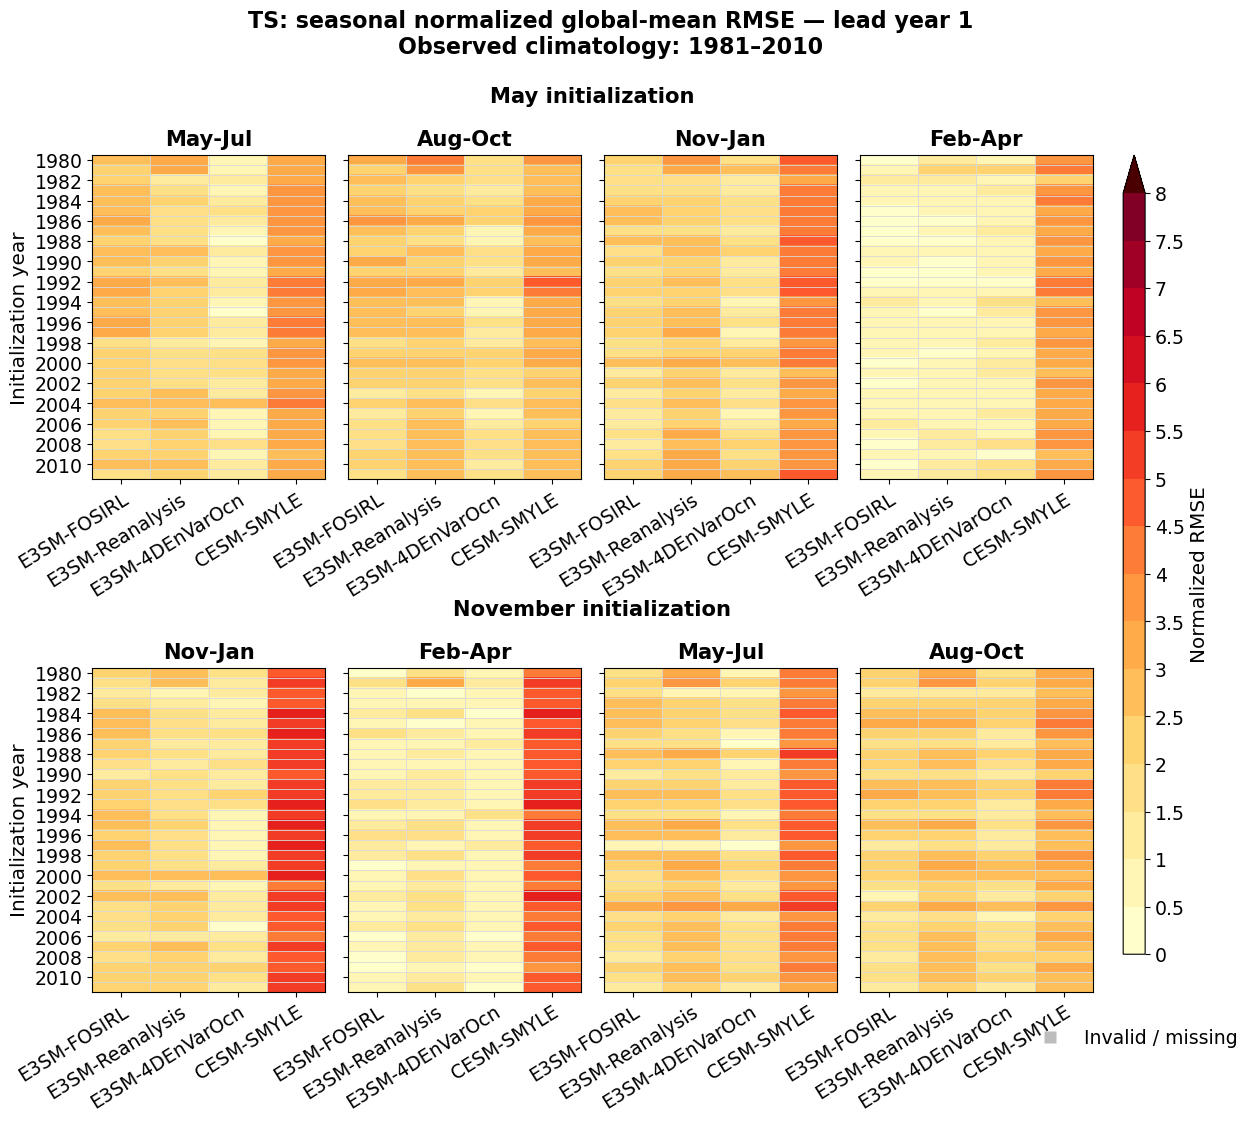

Saved seasonal error comparison: /global/cfs/cdirs/e3sm/www/zhan391/e3sm-s2d_diag/fig_shock_error_ts_init1980-2011_clim1981-2010_lead-year-1_seasonal_normalized_rmse.png


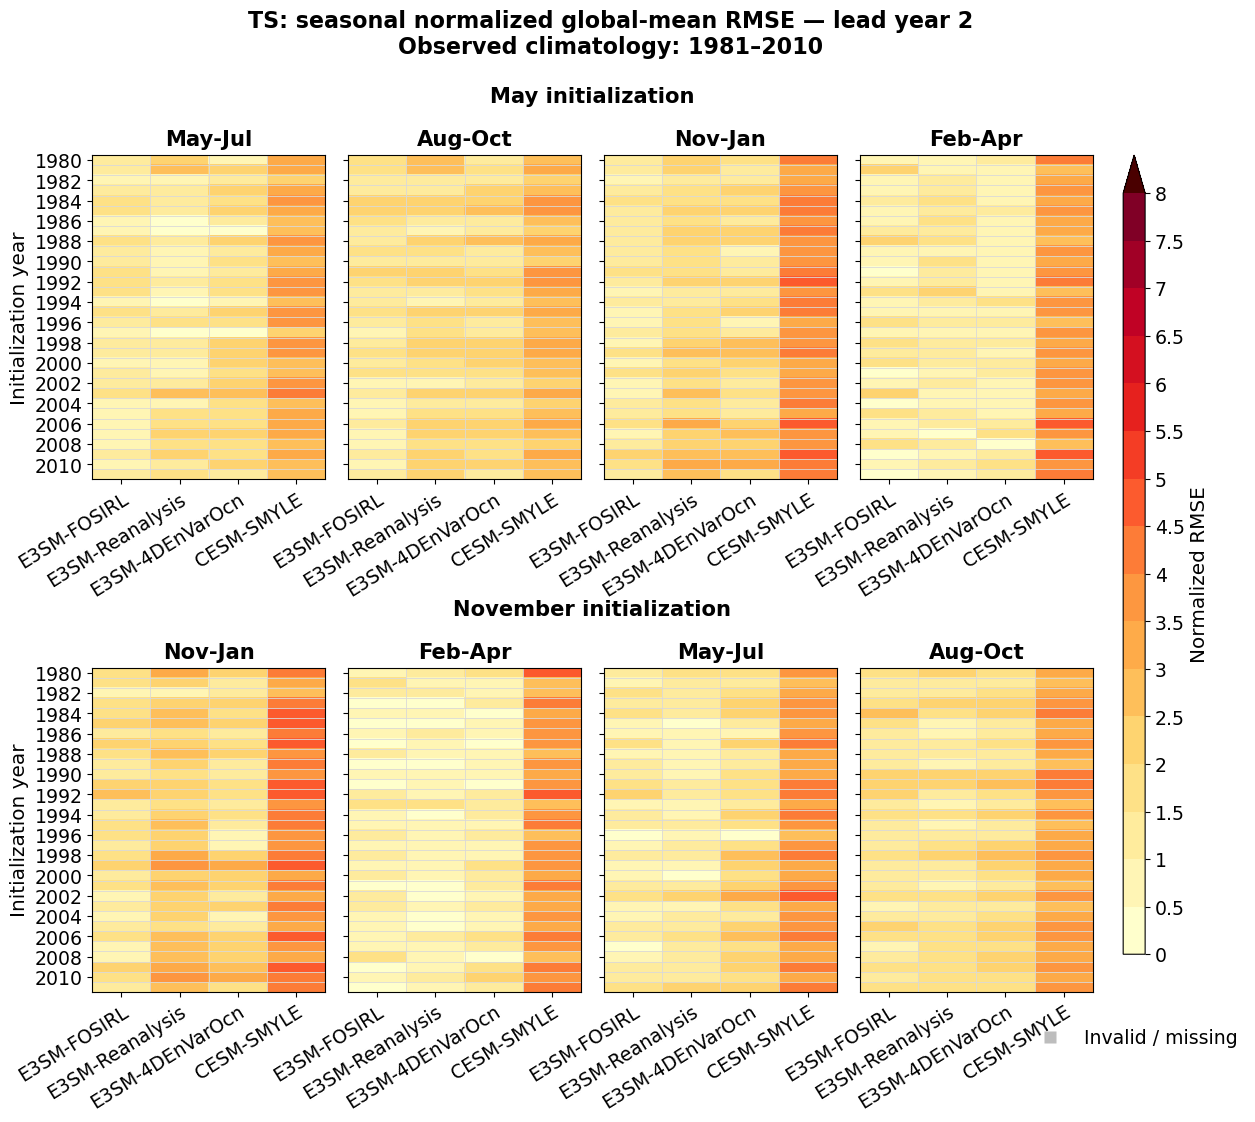

Saved seasonal error comparison: /global/cfs/cdirs/e3sm/www/zhan391/e3sm-s2d_diag/fig_shock_error_ts_init1980-2011_clim1981-2010_lead-year-2_seasonal_normalized_rmse.png


In [7]:
# ===================================================================
# SETUP & PLOT CONTROLS
# Shared helpers read these controls when called by this plotting cell.
# ===================================================================
fontz = 16
TITLE_FONTSIZE = fontz * 1.0
ROW_TITLE_FONTSIZE = fontz * 0.95
PANEL_FONTSIZE = fontz * 0.95
LABEL_FONTSIZE = fontz * 0.90
X_TICK_FONTSIZE = fontz * 0.85
Y_TICK_FONTSIZE = fontz * 0.85
COLORBAR_TICK_FONTSIZE = fontz * 0.85
LEGEND_FONTSIZE = fontz * 0.85

FIGSIZE = (12.2, 10.8)
SUBPLOTS_ADJUST = dict(left=.075, right=.895, bottom=.065, top=.84,
                       wspace=.10, hspace=.58)
COLORBAR_AX = [.92, .10, .018, .74]
ROW_TITLE_OFFSET = .045
ROW_TITLE_KW = dict(ha='center', va='bottom', fontsize=ROW_TITLE_FONTSIZE, fontweight='bold')
PANEL_TITLE_KW = dict(fontsize=PANEL_FONTSIZE, fontweight='bold', pad=7)
SUPTITLE_KW = dict(y=.975, fontsize=TITLE_FONTSIZE, fontweight='bold', linespacing=1.15)
X_TICK_KW = dict(rotation=32, ha='right', rotation_mode='anchor')
MAX_YEAR_LABELS = 17
Y_LABEL = 'Initialization year'
MONTH_NAMES = {5: 'May', 11: 'November'}

ERROR_HEATMAP_LEVELS = np.arange(0.0, 8.0 + 0.5, 0.5)
HEATMAP_CMAP = 'YlOrRd'
HEATMAP_BAD_COLOR = '#bdbdbd'
HEATMAP_OVER_COLOR = '#4a0000'
GRID_KW = dict(which='minor', color='#d9d9d9', linewidth=.6)
COLORBAR_KW = dict(extend='max')
COLORBAR_LABEL = 'Normalized RMSE'
INVALID_HANDLE_KW = dict(marker='s', linestyle='none', markersize=8,
                         markeredgecolor='none', label='Invalid / missing')
LEGEND_KW = dict(loc='upper center', bbox_to_anchor=(.5, -.075), frameon=False,
                 fontsize=LEGEND_FONTSIZE)
SAVE_KW = dict(dpi=300, bbox_inches='tight', pad_inches=.08)

PLOT_SEASONAL_ERROR_HEATMAPS = True

# ===================================================================
# HELPERS, DATA & PLOTTING
# ===================================================================
if not PLOT_SEASONAL_ERROR_HEATMAPS:
    print('Seasonal error heatmaps skipped.')
else:
    first = comparison_by_month[plot_months[0]]
    lead_years = list(map(int, first.lead_year.values))
    season_numbers = list(map(int, first.season.values))
    for lead_year in lead_years:
        fig, axes, cax = compact_heatmap_grid(
            len(plot_months), len(season_numbers), figsize=FIGSIZE,
        )
        for row, month in enumerate(plot_months):
            comparison = comparison_by_month[month]
            labels = list(map(str, comparison.season_label.values))
            for col, season in enumerate(season_numbers):
                ax = axes[row, col]
                panel = comparison.seasonal_normalized_rmse.sel(
                    lead_year=lead_year, season=season,
                ).to_dataset(name='normalized_rmse')
                plot_error_heatmap(
                    panel, variable='normalized_rmse', levels=ERROR_HEATMAP_LEVELS,
                    ax=ax, add_colorbar=False, add_invalid_legend=False,
                    title=labels[col],
                )
                style_error_heatmap(ax)
                ax.set_title(labels[col], **PANEL_TITLE_KW)
                ax.set_ylabel(Y_LABEL if col == 0 else '', fontsize=LABEL_FONTSIZE)
                set_readable_year_ticks(ax, comparison.Y.values)
                if col:
                    ax.tick_params(labelleft=False)
                ax.tick_params(axis='x', bottom=True, labelbottom=True, labelsize=X_TICK_FONTSIZE)
                plt.setp(
                    ax.get_xticklabels(), **X_TICK_KW,
                )
            add_initialization_heading(
                fig, axes[row],
                f"{MONTH_NAMES.get(month, f'Month {month:02d}')} initialization",
            )

        add_shared_error_colorbar(fig, cax, axes[0, 0].images[0])
        fig.suptitle(
            f'{field}: seasonal normalized global-mean RMSE — lead year {lead_year}\n'
            f'Observed climatology: {climo_start}–{climo_end}',
            **SUPTITLE_KW,
        )
        figure_path = FIGURE_ROOT / (
            f'fig_shock_error_{field.lower()}_{period_token}_lead-year-{lead_year}_seasonal_normalized_rmse.png'
        )
        fig.savefig(figure_path, **SAVE_KW)
        plt.show()
        plt.close(fig)
        print('Saved seasonal error comparison:', figure_path)


## Cleanup

The shared 6a indices and compact monthly-error products remain cached. This
idempotent safety cell releases any remaining distributed resources.


In [8]:
close_notebook_resources(globals())
print('Closed notebook Dask resources.')


Closed notebook Dask resources.
